# Data transformation and model training

In [3]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
orig_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\irrigation_prediction.csv'
train_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\train.csv'
test_path = r'E:\Graduation Project\AgriVision\AI\Irrigation-Recommendation-ML-Model\data\raw\test.csv'

orig_df = pd.read_csv(orig_path)
train_df = pd.read_csv(train_path).dropna(subset=['Irrigation_Need'])
test_df = pd.read_csv(test_path)

print(f'Train:     {train_df.shape}')
print(f'Test:      {test_df.shape}')
print(f'Original:  {orig_df.shape}')

Train:     (630000, 21)
Test:      (270000, 20)
Original:  (10000, 20)


In [5]:
categorical_cols = orig_df.select_dtypes(include=['object']).columns
numerical_cols = orig_df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['gSoil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')
Numerical Columns: Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')


In [6]:
# Label Encoding for categorical columns
le = LabelEncoder()
for col in categorical_cols:
    orig_df[col] = le.fit_transform(orig_df[col])

# MinMax Scaling for numerical columns
scaler = MinMaxScaler()
orig_df[numerical_cols] = scaler.fit_transform(orig_df[numerical_cols])

orig_df.head()

,gSoil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,0.394118,0.499649,0.092308,0.608824,0.330000,0.088429,0.467057,0.001429,0.075385,5,3,1,2,2,0.301361,1,0.016337,3,1
1,3,0.473529,0.746667,0.061538,0.038235,0.816667,0.014429,0.332452,0.960000,0.836923,1,0,2,0,0,0.810884,1,0.279570,0,2
2,2,0.855882,0.562632,0.607692,0.611765,0.994333,0.734429,0.737832,0.535714,0.950256,0,1,1,1,2,0.355102,1,0.288405,3,1
3,0,0.341176,0.083333,0.969231,0.088235,0.840667,0.261714,0.122386,0.700000,0.561026,5,2,0,0,2,0.076871,1,0.700258,2,2
4,0,0.870588,0.185614,0.500000,0.711765,0.346000,0.877714,0.750307,0.912857,0.551795,0,2,2,0,3,0.151020,0,0.507127,3,2


In [7]:
X = orig_df.drop("Irrigation_Need", axis=1)
y = orig_df["Irrigation_Need"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 19)
Test Shape: (2000, 19)


In [8]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-"*50)

Logistic Regression Accuracy: 0.7225
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.22      0.34        67
           1       0.77      0.83      0.80      1173
           2       0.65      0.60      0.62       760

    accuracy                           0.72      2000
   macro avg       0.71      0.55      0.59      2000
weighted avg       0.72      0.72      0.72      2000

Confusion Matrix:
[[ 15   1  51]
 [  0 972 201]
 [  6 296 458]]
--------------------------------------------------
Decision Tree Accuracy: 0.9960
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        67
           1       1.00      1.00      1.00      1173
           2       0.99      0.99      0.99       760

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion

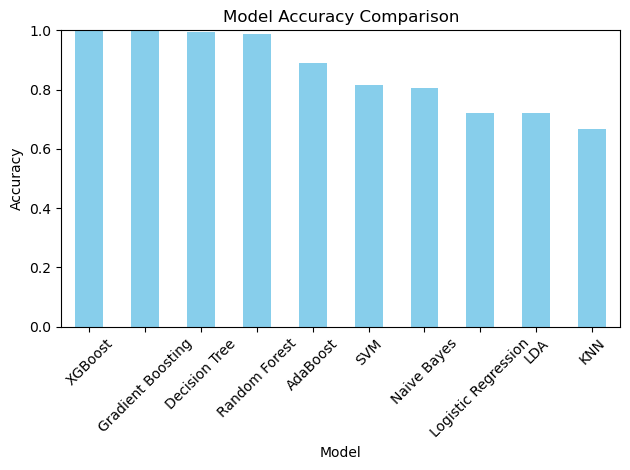

In [10]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
results_df.plot(x='Model', y='Accuracy', kind='bar', legend=False, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
results_df

,Model,Accuracy
9,XGBoost,0.9985
3,Gradient Boosting,0.9965
1,Decision Tree,0.9960
2,Random Forest,0.9860
4,AdaBoost,0.8905
6,SVM,0.8150
7,Naive Bayes,0.8060
0,Logistic Regression,0.7225
8,LDA,0.7220
5,KNN,0.6660


In [14]:
print("Model Performance Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")        
    
    

Model Performance Comparison:
Logistic Regression: 0.7225
Decision Tree: 0.9960
Random Forest: 0.9860
Gradient Boosting: 0.9965
AdaBoost: 0.8905
KNN: 0.6660
SVM: 0.8150
Naive Bayes: 0.8060
LDA: 0.7220
XGBoost: 0.9985


In [20]:
print("Best Model:")
print("Model: ", results_df.iloc[0]['Model'])
print("Accuracy: ", f"{results_df.iloc[0]['Accuracy']*100:.2f}%")

Best Model:
Model:  XGBoost
Accuracy:  99.85%


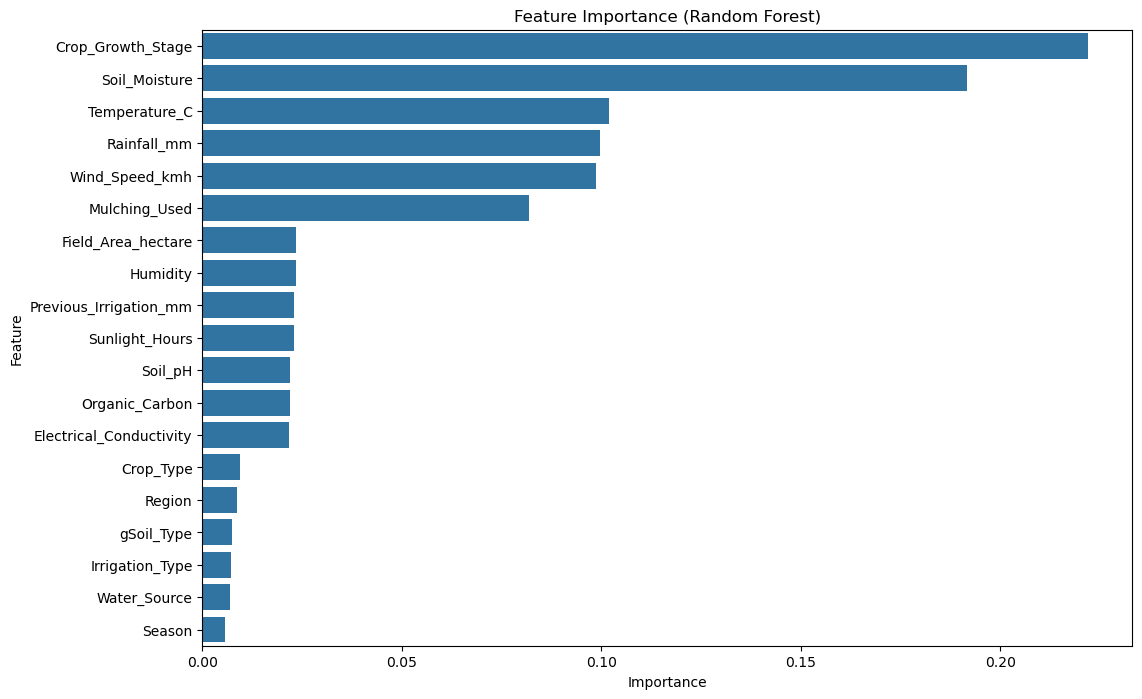

In [28]:
# Using Random Forest as example
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title("Feature Importance (Random Forest)")
plt.show()

## Hyperparameter Tuning Optuna and Experiment Tracking MLFlow

In [22]:
pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric': 'logloss'
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return recall_score(y_test, y_pred, pos_label=1, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Hyperparameters:", study.best_params)
print("Best Recall Score:", study.best_value)

[I 2026-04-30 15:12:29,949] A new study created in memory with name: no-name-c0a0096c-0176-4a34-b737-a89179b2942a
[I 2026-04-30 15:12:30,364] Trial 0 finished with value: 0.9596306616957837 and parameters: {'n_estimators': 248, 'learning_rate': 0.11642135065964075, 'max_depth': 9, 'subsample': 0.5137772519512338, 'min_child_weight': 10, 'gamma': 3.668059753447586, 'reg_alpha': 0.059002799685890506, 'reg_lambda': 0.9385410095849217}. Best is trial 0 with value: 0.9596306616957837.
[I 2026-04-30 15:12:30,578] Trial 1 finished with value: 0.9151387139324689 and parameters: {'n_estimators': 148, 'learning_rate': 0.2549601382676382, 'max_depth': 5, 'subsample': 0.510949186956123, 'min_child_weight': 9, 'gamma': 3.3638530489556913, 'reg_alpha': 3.7148991165219596, 'reg_lambda': 4.573941796717898}. Best is trial 0 with value: 0.9596306616957837.
[I 2026-04-30 15:12:30,979] Trial 2 finished with value: 0.9648899577135635 and parameters: {'n_estimators': 271, 'learning_rate': 0.1285096629125503

Best Hyperparameters: {'n_estimators': 191, 'learning_rate': 0.13667799171771194, 'max_depth': 7, 'subsample': 0.7325951273083268, 'min_child_weight': 7, 'gamma': 0.06599951659538898, 'reg_alpha': 3.318716307851556, 'reg_lambda': 1.2754432281805408}
Best Recall Score: 0.9800995024875622


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

best_params = study.best_params
best_params.update({
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'logloss'    
})

xgb = XGBClassifier(**best_params)

start_train = time.time()
xgb.fit(X_train, y_train)
end_train = time.time() - start_train
print(f"Training Time: {end_train:.2f} seconds")

start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)
end_pred = time.time() - start_pred
print(f"Prediction Time: {end_pred:.2f} seconds")

print("Classification Report for XGBoost:")
print(classification_report(y_test, xgb.predict(X_test), digits=3))

Training Time: 0.41 seconds
Prediction Time: 0.01 seconds
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0      1.000     0.940     0.969        67
           1      1.000     1.000     1.000      1173
           2      0.995     1.000     0.997       760

    accuracy                          0.998      2000
   macro avg      0.998     0.980     0.989      2000
weighted avg      0.998     0.998     0.998      2000

